In [2]:
import os
import time
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [4]:
DATASET_PATH = "/kaggle/input/datasets/arahul22/ee655-q3-data"

TRAIN_DIR = os.path.join(DATASET_PATH, "train")
TEST_DIR = os.path.join(DATASET_PATH, "test")

In [5]:
IMAGE_SIZE = 224
BATCH_SIZE = 32

In [6]:
train_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(8),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

In [7]:
test_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

In [8]:
train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transforms)
test_dataset = datasets.ImageFolder(TEST_DIR, transform=test_transforms)

print("Classes:", train_dataset.classes)

Classes: ['Defective', 'Normal']


In [9]:
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size

train_data, val_data = random_split(train_dataset, [train_size, val_size])

print("Train:", len(train_data))
print("Validation:", len(val_data))

Train: 355
Validation: 89


In [31]:
print("Test:",len(test_dataset))

Test: 111


In [10]:
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [11]:
num_classes = len(train_dataset.classes)
print("Number of classes:", num_classes)

Number of classes: 2


In [12]:
def build_model(model_name):

    if model_name == "resnet50":

        model = models.resnet50(pretrained=True)
        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, num_classes)

    elif model_name == "densenet121":

        model = models.densenet121(pretrained=True)
        in_features = model.classifier.in_features
        model.classifier = nn.Linear(in_features, num_classes)

    elif model_name == "efficientnet":

        model = models.efficientnet_b0(pretrained=True)
        in_features = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(in_features, num_classes)

    return model.to(device)

In [13]:
def train_epoch(model, loader, criterion, optimizer):

    model.train()

    running_loss = 0
    preds = []
    targets = []

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)

        preds.extend(predicted.cpu().numpy())
        targets.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    acc = accuracy_score(targets, preds)

    return epoch_loss, acc

In [14]:
def validate(model, loader, criterion):

    model.eval()

    running_loss = 0
    preds = []
    targets = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)

            preds.extend(predicted.cpu().numpy())
            targets.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    acc = accuracy_score(targets, preds)

    return epoch_loss, acc, targets, preds

In [15]:
def train_model(model_name, epochs=10):

    model = build_model(model_name)

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(model.parameters(), lr=0.0001)

    best_acc = 0
    best_model = copy.deepcopy(model.state_dict())

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }

    for epoch in range(epochs):

        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)

        val_loss, val_acc, targets, preds = validate(model, val_loader, criterion)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        if val_acc > best_acc:
            best_acc = val_acc
            best_model = copy.deepcopy(model.state_dict())

        print(f"{model_name} Epoch {epoch+1}/{epochs}")
        print("Train Acc:", train_acc, "Val Acc:", val_acc)

    model.load_state_dict(best_model)

    return model, history

In [18]:
resnet_model, resnet_history = train_model("resnet50", epochs=10)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


resnet50 Epoch 1/10
Train Acc: 0.8309859154929577 Val Acc: 0.9101123595505618
resnet50 Epoch 2/10
Train Acc: 0.9633802816901409 Val Acc: 0.9550561797752809
resnet50 Epoch 3/10
Train Acc: 0.9887323943661972 Val Acc: 0.9550561797752809
resnet50 Epoch 4/10
Train Acc: 0.9830985915492958 Val Acc: 0.9662921348314607
resnet50 Epoch 5/10
Train Acc: 0.9915492957746479 Val Acc: 0.9662921348314607
resnet50 Epoch 6/10
Train Acc: 0.9971830985915493 Val Acc: 0.9550561797752809
resnet50 Epoch 7/10
Train Acc: 1.0 Val Acc: 0.9438202247191011
resnet50 Epoch 8/10
Train Acc: 1.0 Val Acc: 0.9775280898876404
resnet50 Epoch 9/10
Train Acc: 1.0 Val Acc: 0.9438202247191011
resnet50 Epoch 10/10
Train Acc: 1.0 Val Acc: 0.9550561797752809


In [17]:
densenet_model, densenet_history = train_model("densenet121", epochs=10)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 147MB/s]


densenet121 Epoch 1/10
Train Acc: 0.8084507042253521 Val Acc: 0.9101123595505618
densenet121 Epoch 2/10
Train Acc: 0.9774647887323944 Val Acc: 0.9438202247191011
densenet121 Epoch 3/10
Train Acc: 0.9830985915492958 Val Acc: 0.9438202247191011
densenet121 Epoch 4/10
Train Acc: 1.0 Val Acc: 0.9550561797752809
densenet121 Epoch 5/10
Train Acc: 0.9971830985915493 Val Acc: 0.9662921348314607
densenet121 Epoch 6/10
Train Acc: 0.9971830985915493 Val Acc: 0.9550561797752809
densenet121 Epoch 7/10
Train Acc: 0.9971830985915493 Val Acc: 0.9438202247191011
densenet121 Epoch 8/10
Train Acc: 1.0 Val Acc: 0.9550561797752809
densenet121 Epoch 9/10
Train Acc: 0.9971830985915493 Val Acc: 0.9662921348314607
densenet121 Epoch 10/10
Train Acc: 0.9943661971830986 Val Acc: 0.9662921348314607


In [20]:
efficientnet_model, efficientnet_history = train_model("efficientnet", epochs=10)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


efficientnet Epoch 1/10
Train Acc: 0.7126760563380282 Val Acc: 0.8314606741573034
efficientnet Epoch 2/10
Train Acc: 0.9267605633802817 Val Acc: 0.8651685393258427
efficientnet Epoch 3/10
Train Acc: 0.9323943661971831 Val Acc: 0.898876404494382
efficientnet Epoch 4/10
Train Acc: 0.9605633802816902 Val Acc: 0.9438202247191011
efficientnet Epoch 5/10
Train Acc: 0.9690140845070423 Val Acc: 0.9550561797752809
efficientnet Epoch 6/10
Train Acc: 0.9887323943661972 Val Acc: 0.9213483146067416
efficientnet Epoch 7/10
Train Acc: 0.9943661971830986 Val Acc: 0.9438202247191011
efficientnet Epoch 8/10
Train Acc: 0.9915492957746479 Val Acc: 0.9550561797752809
efficientnet Epoch 9/10
Train Acc: 0.9971830985915493 Val Acc: 0.9662921348314607
efficientnet Epoch 10/10
Train Acc: 0.9943661971830986 Val Acc: 0.9213483146067416


In [21]:
def evaluate(model):

    model.eval()

    preds = []
    targets = []

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs,1)

            preds.extend(predicted.cpu().numpy())
            targets.extend(labels.numpy())

    acc = accuracy_score(targets, preds)

    cm = confusion_matrix(targets, preds)

    report = classification_report(targets, preds)

    return acc, cm, report

In [22]:
resnet_acc, resnet_cm, resnet_report = evaluate(resnet_model)

densenet_acc, densenet_cm, densenet_report = evaluate(densenet_model)

efficientnet_acc, efficientnet_cm, efficientnet_report = evaluate(efficientnet_model)

print("ResNet50 Accuracy:", resnet_acc)
print("DenseNet121 Accuracy:", densenet_acc)
print("EfficientNet Accuracy:", efficientnet_acc)

ResNet50 Accuracy: 0.9369369369369369
DenseNet121 Accuracy: 0.963963963963964
EfficientNet Accuracy: 0.954954954954955


In [26]:
def plot_cm(cm, title):

    plt.figure(figsize=(5,4))

    sns.heatmap(cm, annot=True, fmt="d",
                xticklabels=train_dataset.classes,
                yticklabels=train_dataset.classes)

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(title)

    plt.show()

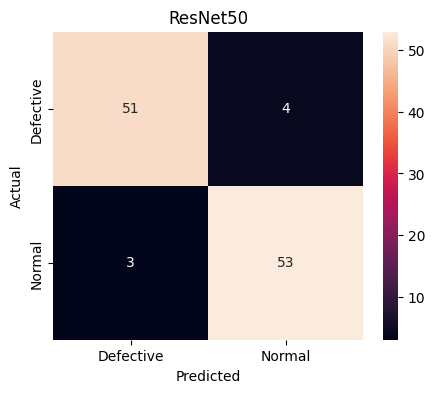

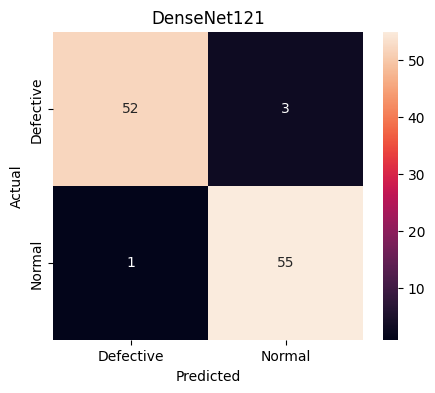

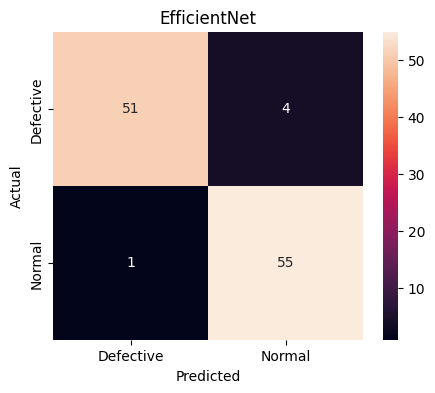

In [24]:
plot_cm(resnet_cm, "ResNet50")

plot_cm(densenet_cm, "DenseNet121")

plot_cm(efficientnet_cm, "EfficientNet")

In [25]:
results = pd.DataFrame({

    "Model": ["ResNet50","DenseNet121","EfficientNet"],

    "Accuracy":[resnet_acc,densenet_acc,efficientnet_acc]

})

results

,Model,Accuracy
0,ResNet50,0.936937
1,DenseNet121,0.963964
2,EfficientNet,0.954955
